In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
path = '/content/drug200.csv'
df = pd.read_csv(path)

# Display first 5 rows
print(f"Data Loaded Successfully. Shape: {df.shape}")
df.head()

Data Loaded Successfully. Shape: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [2]:
from sklearn.preprocessing import LabelEncoder

# Initialize Encoder
le = LabelEncoder()

# Encode Categorical Columns (Convert words to numbers)
# This is applied to Sex, BP, Cholesterol, and the Target (Drug)
cols_to_encode = ['Sex', 'BP', 'Cholesterol', 'Drug']

for col in cols_to_encode:
    df[col] = le.fit_transform(df[col])

print("Preprocessing Complete: All text converted to numbers.")
df.head()

Preprocessing Complete: All text converted to numbers.


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [3]:
# Check for Outliers in 'Na_to_K' (Numerical Feature)
Q1 = df['Na_to_K'].quantile(0.25)
Q3 = df['Na_to_K'].quantile(0.75)
IQR = Q3 - Q1

# Filter Outliers
df = df[~((df['Na_to_K'] < (Q1 - 1.5 * IQR)) | (df['Na_to_K'] > (Q3 + 1.5 * IQR)))]

print(f"Outliers Removed. New Shape: {df.shape}")

Outliers Removed. New Shape: (192, 6)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
X = df.drop('Drug', axis=1)
y = df['Drug']

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale Features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split & Scaled Successfully.")
print(f"Training Shape: {X_train_scaled.shape}")
print(f"Testing Shape:  {X_test_scaled.shape}")

Data Split & Scaled Successfully.
Training Shape: (153, 5)
Testing Shape:  (39, 5)


In [5]:
import time
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize Random Forest (100 Trees)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train Model (Measure Time)
start = time.time()
model.fit(X_train_scaled, y_train)
stop = time.time()

print("Random Forest Training Complete.")
print(f"Time Taken: {stop - start:.4f} seconds")

Random Forest Training Complete.
Time Taken: 0.3053 seconds


In [6]:
from sklearn.metrics import accuracy_score, log_loss, classification_report

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Log Loss: {log_loss(y_test, y_prob):.4f}\n")

print("--- Drug Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy: 97.44%
Log Loss: 0.1632

--- Drug Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.89      1.00      0.94         8
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00        13

    accuracy                           0.97        39
   macro avg       0.98      0.93      0.95        39
weighted avg       0.98      0.97      0.97        39



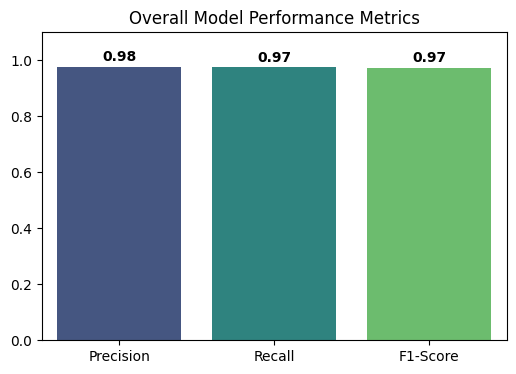

In [14]:
from sklearn.metrics import precision_recall_fscore_support

# Get weighted averages for the metrics
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

# Create Bar Graph
metrics = ['Precision', 'Recall', 'F1-Score']
values = [prec, rec, f1]

plt.figure(figsize=(6, 4))
sns.barplot(x=metrics, y=values, hue=metrics, legend=False, palette='viridis')

plt.title('Overall Model Performance Metrics')
plt.ylim(0, 1.1)

# Add numbers on top
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

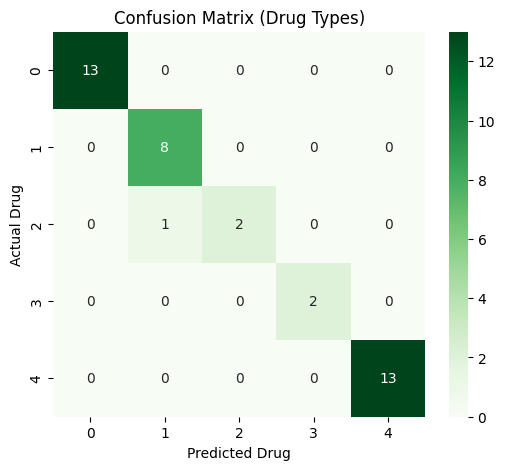

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Drug Types)')
plt.xlabel('Predicted Drug')
plt.ylabel('Actual Drug')
plt.show()

In [18]:
# Lists to store history
n_trees = [10, 20, 40, 60, 80, 100]
acc_hist, loss_hist, time_hist = [], [], []

print("Training models to generate graph data.")

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    t0 = time.time()
    rf.fit(X_train_scaled, y_train)
    time_hist.append(time.time() - t0)

    # Record Metrics
    y_p = rf.predict(X_test_scaled)
    y_pb = rf.predict_proba(X_test_scaled)
    acc_hist.append(accuracy_score(y_test, y_p))
    loss_hist.append(log_loss(y_test, y_pb))

print("Calculation Complete! Graphs can be plotted now.")

Training models to generate graph data.
Calculation Complete! Graphs can be plotted now.


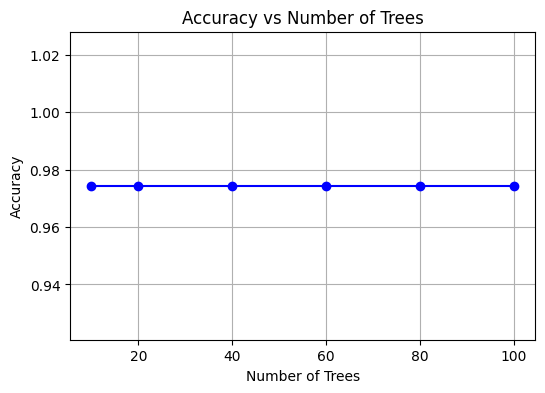

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(n_trees, acc_hist, 'o-', color='blue')
plt.title('Accuracy vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

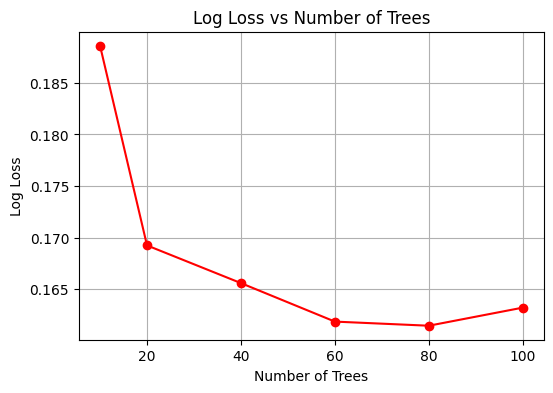

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(n_trees, loss_hist, 'o-', color='red')
plt.title('Log Loss vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()

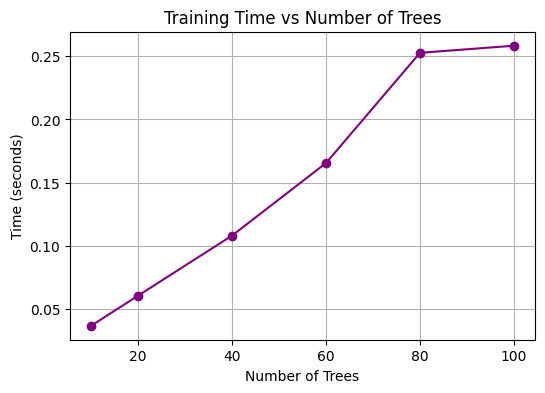

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(n_trees, time_hist, 'o-', color='purple')
plt.title('Training Time vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.show()

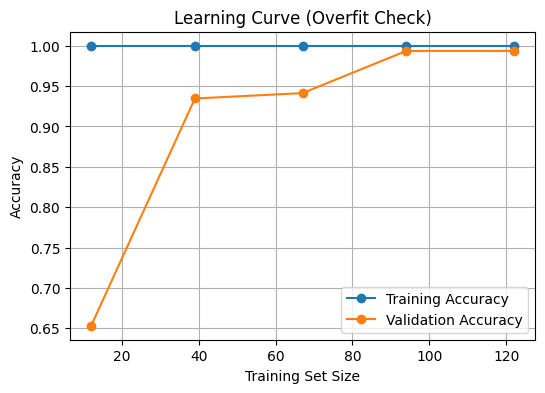

In [22]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Accuracy')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Validation Accuracy')
plt.title('Learning Curve (Overfit Check)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()